# INF8111 - Fouille de données


## TP1 AUTOMNE 2025 - Préparation de données




### Instructions de remise

#### Membres de l'équipe :
    - Le Chevallier Ethan (2488083) 1
    - Gagné Cédric (2147286) 2
    - Cong Minh Dinh (Matricule) 3

#### Numéro du groupe :
    - TP - Groupe 54
    
#### Livrable :

Vous devez soumettre ce notebook sur Moodle dans la boite de remise sous le nom TP1_NumeroGroupe_matricule1_matricule2_matricule3.ipynb .

**NB**: Tout travail en retard sera pénalisé d'une valeur de 10\% par jour de retard.


## Introduction et objectifs

### Importation des différents modules

In [1]:
!pip install pandas
!pip install numpy
!pip install scikit-learn
!pip install seaborn
!pip install matplotlib
!pip install plotly
!pip install shap

In [2]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn import preprocessing
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
import shap

### Lecture des données

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv('/content/drive/MyDrive/TP1 INF8111/data.csv')

Le but de ce notebook est d'effectuer le prétraitement du dataset [HousePricePrediction](https://docs.google.com/spreadsheets/d/1caaR9pT24GNmq3rDQpMiIMJrmiTGarbs/edit#gid=1150341366) qui pourra être par la suite être utilisé pour entraîner un modèle de prédiction de prix de maisons.

## Préparation des données

Plusieurs étapes sont nécessaires pour préparer un dataset pour la fouille des données
- **Nettoyage des données** :
    - Suppression des attributs inutiles
    - Gestion des valeurs manquantes
    - Gestion des valeurs aberrantes
- **Transformation des données** :
    - Encodage des données
    - Normalisation des données
- **Sélection des attributs** :
    - Suppression des attributs les plus fortement corrélés

<a id="exploration-des-donnees"></a>
## 1. Exploration des données (5 points)

Nous vous avons fourni le fichier *data.csv* avec l'exécution de la deuxième cellule. Il contient l'ensemble des données. Chaque ligne contient les données d'une vente. La description des attributs du dataset est la suivante:

| # | Feature Name | Description |
|---|--------------|-------------|
| 1 | Id           | Numéro de vente / To count the records. |
| 2 | MSSubClass   | Type de logement / Identifies the type of dwelling involved in the sale. |
| 3 | MSZoning     | Zonage / Identifies the general zoning classification of the sale. |
| 4 | LotArea      | Superficie du logement / Lot size in square feet. |
| 5 | LotConfig    | Configuration du logement / Configuration of the lot |
| 6 | BldgType     | Type de logement / Type of dwelling |
| 7 | OverallCond  | Etat général / Rates the overall condition of the house |
| 8 | YearBuilt    | Année de contruction / Original construction year |
| 9 | YearRemodAdd | Année de rénovation / Remodel date (same as construction date if no remodeling or additions). |
| 10| Exterior1st  | Type de revêtement extérieur / Exterior covering on house |
| 11| BsmtFinSF2   | Surface de vie / Type 2 finished square feet. |
| 12| TotalBsmtSF  | Surface totale de la base / Total square feet of basement area |
| 13| SalePrice    | Prix de vente à prédire / To be predicted |

On visualise le dataset pour avoir une idée de ce qu'il contient et des prétraitements à effectuer.

### 1.1 - Question 1 (2.5 points)

**Combien d'observations contient le dataset ? Quelles sont les types des attributs du dataset ?**

In [5]:
print("shape:", df.shape)
print(df.dtypes)

shape: (2919, 13)
Id                int64
MSSubClass        int64
MSZoning         object
LotArea           int64
LotConfig        object
BldgType         object
OverallCond       int64
YearBuilt         int64
YearRemodAdd      int64
Exterior1st      object
BsmtFinSF2      float64
TotalBsmtSF     float64
SalePrice       float64
dtype: object


On distingue 2919 observations.

On compte 13 attributs (12 + Id)

Les attributs du dataset correspondent aux caractéristiques de la vente

On distingue notamment 3 types des attributs différents :
- des entiers numériques int64 (Id, MSSubClass, LotArea, OverallCond, YearBuilt, YearRemodAdd)
- des réels float64 (BsmtFinSF2, TotalBsmtSF, SalePrice)
- des objects (MSZoning, LotConfig, BldgType, Exterior1st)

### 1.2 - Question 2 (2.5 points)

**Quelles sont les valeurs uniques des attributs de type `object` ?**

In [6]:
for col in df.select_dtypes(include="object").columns:
    print(col, ":", df[col].unique())

MSZoning : ['RL' 'RM' 'C (all)' 'FV' 'RH' nan]
LotConfig : ['Inside' 'FR2' 'Corner' 'CulDSac' 'FR3']
BldgType : ['1Fam' '2fmCon' 'Duplex' 'TwnhsE' 'Twnhs']
Exterior1st : ['VinylSd' 'MetalSd' 'Wd Sdng' 'HdBoard' 'BrkFace' 'WdShing' 'CemntBd'
 'Plywood' 'AsbShng' 'Stucco' 'BrkComm' 'AsphShn' 'Stone' 'ImStucc'
 'CBlock' nan]


Pour chacun des attributs de type object, on donne les valeurs uniques :
- MSZoning : RL, RM, C (all), FV, RH, nan
- LotConfig : Inside, FR2, Corner, CulDSac, FR3
- BldgType : 1Fam, 2fmCon, Duplex, TwnhsE, Twnhs
- Exterior1st : VinylSd, MetalSd, Wd Sdng, HdBoard, BrkFace, WdShing, Stucco, Plywood, CemntBd, AsbShng, BrkComm, AsphShn, Stone, ImStucc, CBlock, nan

Les nan correspondent aux attributs avec des valeurs manquantes.

<a id="nettoyage-des-donnees"></a>
## 2. Nettoyage des données (30 points)

<a id="suppression-des-attributs-inutiles"></a>
### 2.1 Suppression des attributs inutiles

### 2.1.1 - Question 3 (5 points)

**Pourquoi on peut supprimer l'attribut `Id` dans le cas de ce TP? Effectuez cette suppression.**

#Réponse

Ici, l'Id correspond à un numéro de ligne et non à un numéro pour identifier chaque vente. Dans ce cas, on peut faire le choix de supprimer cet attribut sans perturber la fouille de données sur ce dataset car il ne permet pas de prédire le résultat concernant SalePrice.

In [7]:
if "Id" in df.columns:
    df = df.drop(columns=["Id"])

In [8]:
print("shape:", df.shape)
print(df.dtypes)

shape: (2919, 12)
MSSubClass        int64
MSZoning         object
LotArea           int64
LotConfig        object
BldgType         object
OverallCond       int64
YearBuilt         int64
YearRemodAdd      int64
Exterior1st      object
BsmtFinSF2      float64
TotalBsmtSF     float64
SalePrice       float64
dtype: object


On a bien perdu l'ID par rapport à la première question.

<a id="gestion-des-valeurs-manquantes"></a>
### 2.2 Gestion des valeurs manquantes

Pour gérer les valeurs manquantes, plusieurs solutions s'offrent à nous :
- Remplacer par la valeur la plus fréquente (le mode)
- Remplacer par la valeur moyenne/médiane
- Suppression des lignes contenant des valeurs manquantes

Pour ce TP, nous optons pour la dernière option.

#### 2.2.1 - Question 4 (2.5 points)

**Quels sont les attributs qui contiennent des valeurs manquantes ?**

Pour cette question, on peut raisonner sur les NaN qui correspondent aux valeurs manquantes pour chaque attribut.

In [9]:
for col in df.columns:
    print(f"\nColonne: {col}")
    print(" - Nombre de NaN :", df[col].isnull().sum())
    print(" - Valeurs uniques :", df[col].unique())


Colonne: MSSubClass
 - Nombre de NaN : 0
 - Valeurs uniques : [ 60  20  70  50 190  45  90 120  30  85  80 160  75 180  40 150]

Colonne: MSZoning
 - Nombre de NaN : 4
 - Valeurs uniques : ['RL' 'RM' 'C (all)' 'FV' 'RH' nan]

Colonne: LotArea
 - Nombre de NaN : 0
 - Valeurs uniques : [ 8450  9600 11250 ...  1894 20000 10441]

Colonne: LotConfig
 - Nombre de NaN : 0
 - Valeurs uniques : ['Inside' 'FR2' 'Corner' 'CulDSac' 'FR3']

Colonne: BldgType
 - Nombre de NaN : 0
 - Valeurs uniques : ['1Fam' '2fmCon' 'Duplex' 'TwnhsE' 'Twnhs']

Colonne: OverallCond
 - Nombre de NaN : 0
 - Valeurs uniques : [5 8 6 7 4 2 3 9 1]

Colonne: YearBuilt
 - Nombre de NaN : 0
 - Valeurs uniques : [2003 1976 2001 1915 2000 1993 2004 1973 1931 1939 1965 2005 1962 2006
 1960 1929 1970 1967 1958 1930 2002 1968 2007 1951 1957 1927 1920 1966
 1959 1994 1954 1953 1955 1983 1975 1997 1934 1963 1981 1964 1999 1972
 1921 1945 1982 1998 1956 1948 1910 1995 1991 2009 1950 1961 1977 1985
 1979 1885 1919 1990 1969 1935 19

On a donc MSZoning, Exterior1st, BSMTFinSF2, TotalBsmtSF et SalePrice qui possèdent des valeurs manquantes.

#### 2.2.2 - Question 5 (2.5 points)

On peut alors gérer les valeurs manquantes colonne par colonne. L'attribut `SalePrice` n'est pas pris en considération car les valeurs manquantes sont justement les valeurs que nous voulons prédire.

**Supprimer les lignes contenant les valeurs manquantes. Implémentez la fonction `delete_missing_values` qui retire ces données**.

In [10]:
def delete_missing_values(dataset):
    ds = dataset.copy()
    cols_with_missing_values = [c for c in ds.columns if c != "SalePrice"]
    ds = ds.dropna(subset=cols_with_missing_values)
    ds = ds.reset_index(drop=True)
    return ds

In [11]:
df = delete_missing_values(df)

Les données manquantes pour la colonne `SalePrice` sont celles du dataset de test. On laisse donc ces valeurs manquantes car on veut appliquer le même prétraitement sur les données de test.

### 2.2.3 - Question 6 (10 points)

On veut néanmoins que les données d'entrainement suivent une distribution gaussienne.

**Implémenter le fonction `plot_hist`. Cette fonction doit permettre d'afficher la distribution des valeurs de l'attribut `SalePrice` ainsi que la loi normale de même moyenne et variance.**

In [12]:
def plot_hist(prices):
    #Paramètres de la loi normale sur les données en entrée
    mu = prices.mean()
    sigma = prices.std()

    # Histogramme
    count, bins, ignored = plt.hist(prices, bins=30, density=True, alpha=0.5, color="skyblue")

    # Loi normale théorique
    x = np.linspace(min(prices), max(prices), 1000)
    y = (1/(sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5*((x - mu)/sigma)**2)
    plt.plot(x, y, color="red", linewidth=2)

    # Affichage du titre et des labels
    plt.title("Distribution de SalePrice avec loi normale théorique")
    plt.xlabel("SalePrice")
    plt.ylabel("Densité de répartition du SalePrice")
    plt.show()

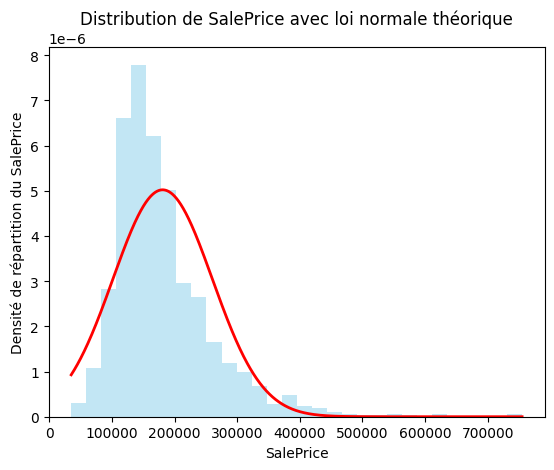

In [13]:
plot_hist(df['SalePrice'])

Vous devez obtenir une distribution des valeurs de `SalePrice` proches d'une distribution normale mais légèrement asymétrique. On peut alors appliquer une transformation logarithmique pour approcher d'une distribution normale symétrique.

**Effectuer cette transformation sur notre ensemble de données.**

In [14]:
df["SalePrice"] = np.log1p(df["SalePrice"])  # log(1+x) préféré en cas de valeurs nulles dans le dataset

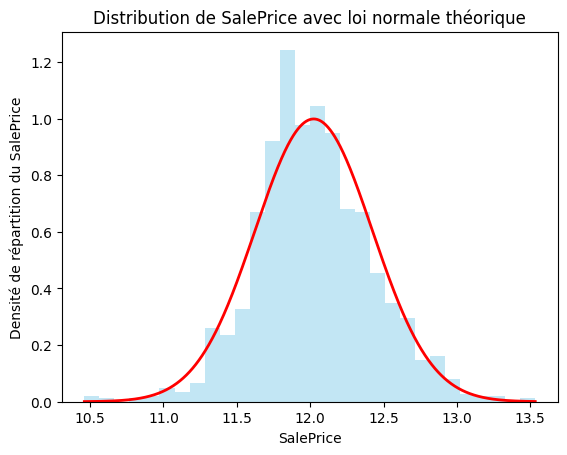

In [15]:
plot_hist(df['SalePrice'])

On remarque que la transformation logarithmique permet d'approcher une distribution normale symétrique.

In [16]:
# Cette copie va servir plus tard pour la partie 6 (à partir de la question 17 (IQR))
df_order1 = df.copy()

<a id="detection-des-valeurs-aberrantes"></a>
### 2.3 Détection des valeurs aberrantes

En pratique, la méthode de détection d'une valeur aberrante nécessite de se poser les questions suivantes:
- Quelles valeurs seraient incohérentes pour chaque colonne ?
- Quelles valeurs peuvent être problématiques pour l'utilisation de ces données ? Exemple: pour une régression linéaire, on préfère avoir des valeurs distribuées suivant une loi normale.

Avec ces éléments, on peut:
- Fixer des seuils de tolérance pour les valeurs aberrantes
- Utiliser des algorithmes de détection de valeurs aberrantes (ex: clustering, IRQ, [QTest](https://plotly.com/python/v3/outlier-test/), ...)

A noter que suivant les méthodes, les valeurs détectées comme aberrantes peuvent être différentes.

La méthode IRQ fait l'objet d'une question, en fin de ce notebook.

### 2.3.1 Question 7 (10 points)

Ici comme nous allons réaliser une régression linéaire, nous allons visuellement voir si certains points s'écartent largement de la droite de régression.

On sait que l'on veut effectuer une régression linéaire pour prédire `SalePrice`. On peut donc visualiser les valeurs de chaque attribut en fonction de `SalePrice` pour détecter la présence de valeurs aberrantes.

**Implémenter la fonction `plot_line`. Elle doit permettre de visualiser la relation entre un attribut donné et `SalePrice`.**

In [17]:
def plot_line(attr):
    X = df[[attr]]
    y = df["SalePrice"]

    # Supprimer les lignes contenant NaN pour SalePrice
    mask = y.notna()
    X_clean = X[mask]
    y_clean = y[mask]

    # Encodage pour les colonnes de type object
    if not np.issubdtype(X_clean[attr].dtype, np.number):
        X_plot = X_clean[attr].astype("category").cat.codes.values.reshape(-1,1)
    else:
        X_plot = X_clean.values

    # Régression linéaire avec sklearn
    model = LinearRegression()
    model.fit(X_plot, y_clean)

    # Nuage de points
    plt.scatter(X_plot, y_clean, alpha=0.5, s=15, color="blue")

    # Affichage de la droite de régression
    x_line = np.linspace(X_plot.min(), X_plot.max(), 100).reshape(-1,1)
    y_line = model.predict(x_line)
    plt.plot(x_line, y_line, color="red", linewidth=2, label="Régression linéaire")

    #Affichage du titre et des labels
    plt.xlabel(attr)
    plt.ylabel("SalePrice")
    plt.title(f"Relation entre {attr} et SalePrice")
    plt.legend()
    plt.show()

**Afficher les relations de tous les attributs avec `SalePrice`. Peut-on y déceler des valeurs aberrantes ?**

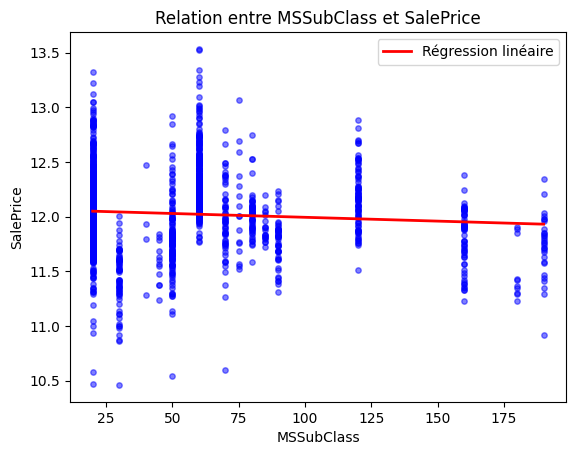

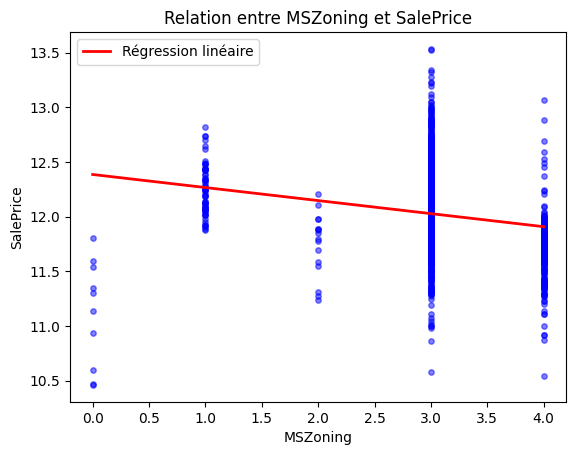

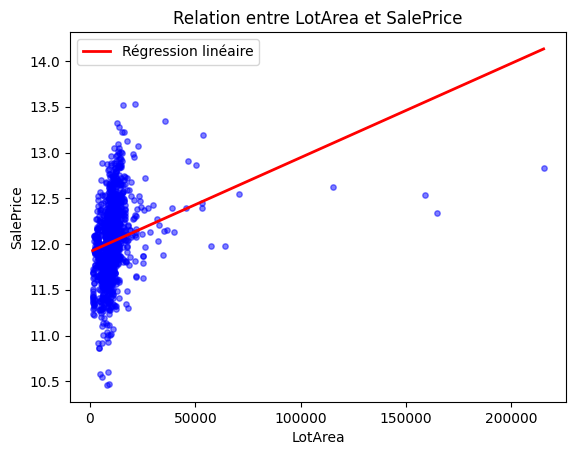

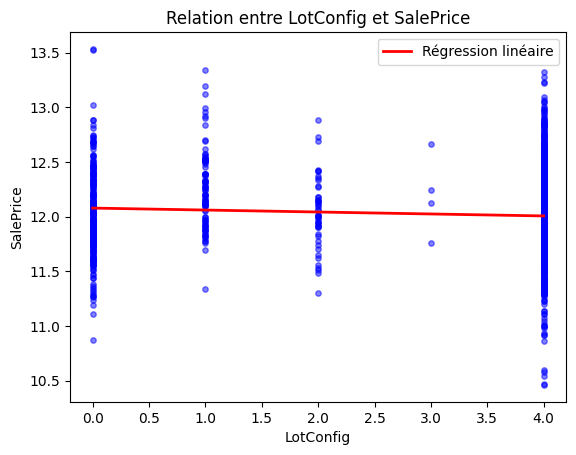

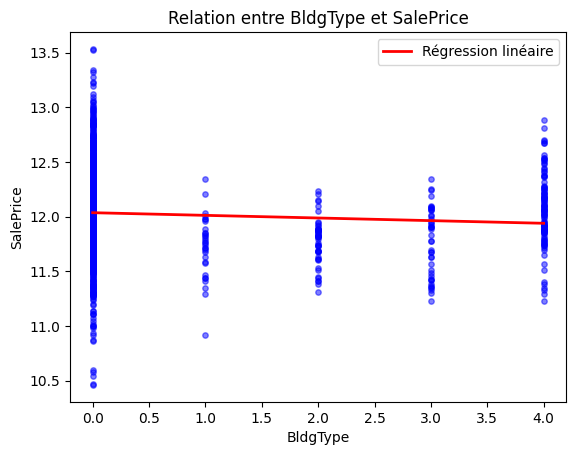

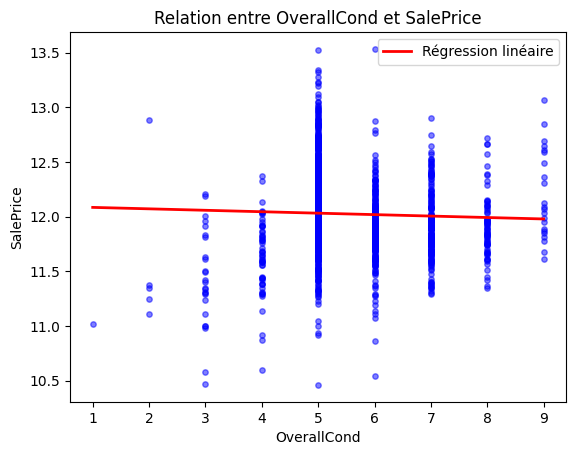

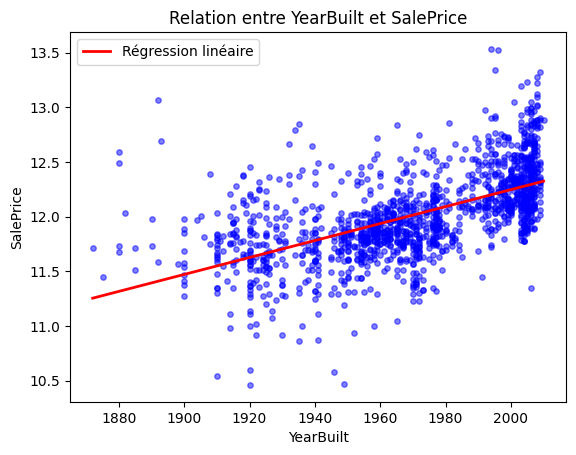

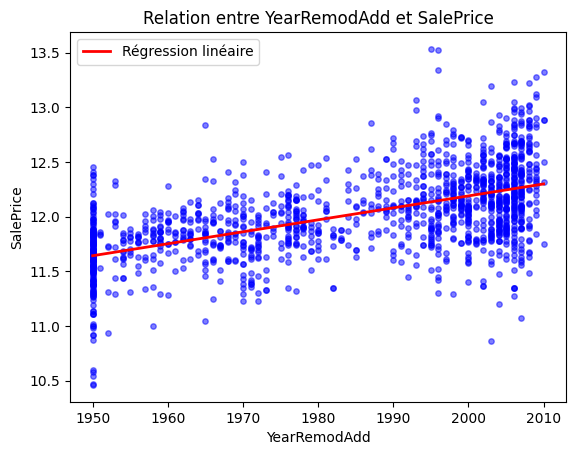

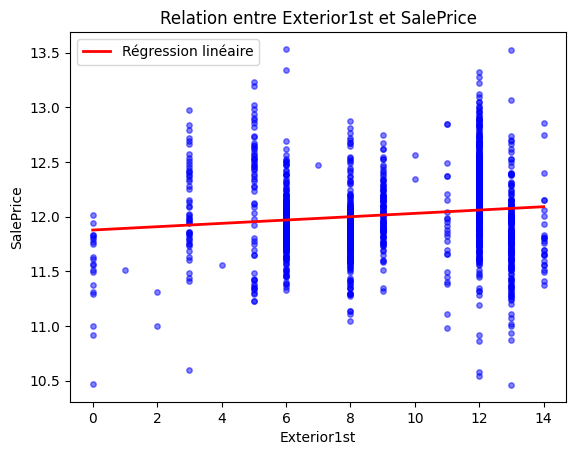

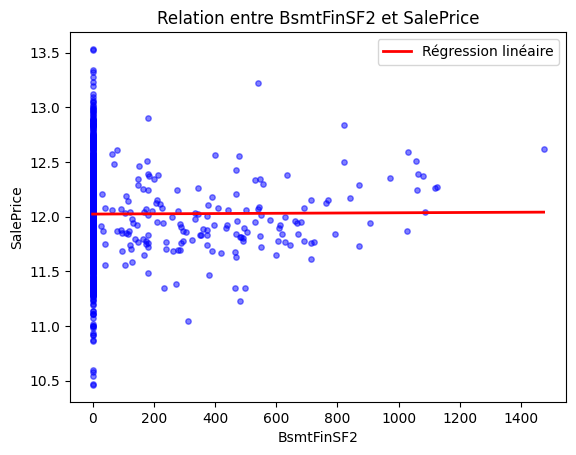

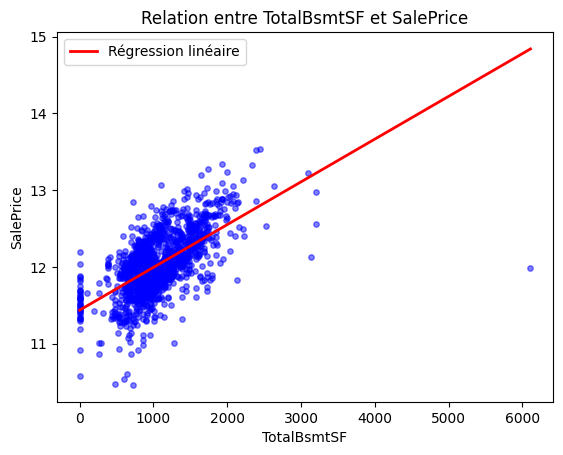

In [18]:
for col in df.columns:
  if col != "SalePrice":
    plot_line(col)

On peut déceler des valeurs aberrantes qui s'éloignent des nuages de données ou alors de la droite de régression pour chaque graphe.

**À ce stade, il s'agit uniquement de détecter la présence éventuelle de valeurs aberrantes dans les données.**
**Aucune action de traitement ou de remplacement n'est demandée pour le moment**

## 3. Transformation des données (10 points)

### 3.1 Encodage des attributs de type `object`

Les attributs de type `object` étant catégoriques (voire partie 1), on peut effectuer un `one hot encoding` de ces attributs. `Pandas` permet d'effectuer cela avec la fonction `get_dummies()`. Cela nous permettra d'obtenir un dataset contenant uniquement des attributs de type `int` ou `float`.


#### 3.1.1 Question 8 (5 points)

**Encodez les attributs de type `object` avec un `one hot encoding`**

In [19]:
df = pd.get_dummies(df, drop_first=True, dtype = int)
print("shape:", df.shape)
print(df.dtypes)

shape: (2913, 34)
MSSubClass               int64
LotArea                  int64
OverallCond              int64
YearBuilt                int64
YearRemodAdd             int64
BsmtFinSF2             float64
TotalBsmtSF            float64
SalePrice              float64
MSZoning_FV              int64
MSZoning_RH              int64
MSZoning_RL              int64
MSZoning_RM              int64
LotConfig_CulDSac        int64
LotConfig_FR2            int64
LotConfig_FR3            int64
LotConfig_Inside         int64
BldgType_2fmCon          int64
BldgType_Duplex          int64
BldgType_Twnhs           int64
BldgType_TwnhsE          int64
Exterior1st_AsphShn      int64
Exterior1st_BrkComm      int64
Exterior1st_BrkFace      int64
Exterior1st_CBlock       int64
Exterior1st_CemntBd      int64
Exterior1st_HdBoard      int64
Exterior1st_ImStucc      int64
Exterior1st_MetalSd      int64
Exterior1st_Plywood      int64
Exterior1st_Stone        int64
Exterior1st_Stucco       int64
Exterior1st_VinylSd  

### 3.2 Normalisation des données

Pour faciliter l'entraînement du modèle, on peut normaliser les données. `sklearn` permet d'effectuer cela avec les fonctions suivantes :

*   `StandardScaler()` normalise les données en soustrayant la moyenne et en divisant par l'écart-type
*   `MinMaxScaler()` normalise les données en les ramenant entre 0 et 1.

Dans la suite de ce TP, nous utiliserons la fonction `StandardScaler()`.

In [20]:
# A utiliser dans la partie 5.2
mu_sale_price = df["SalePrice"].mean()
sigma_sale_price = df["SalePrice"].std()

#### 3.2.1 Question 9 (5 points)

**Implémenter la fonction `normalize`. Elle doit réaliser la normalisation des données.**

In [21]:
def normalize(dataset):
    scaler = preprocessing.StandardScaler()
    cols = dataset.columns
    dataset[cols] = scaler.fit_transform(dataset[cols])
    return dataset

In [22]:
df = normalize(df)

## 4. Sélection des attributs corrélées (15 points)

### 4.1 Suppression des attributs corrélées

Pour améliorer la qualité de la prédiction, nous devons prendre en compte la corrélation entre attributs. L'objectif est donc de supprimer les attributs les plus fortement corrélées entre eux.

Pour ce faire, vous disposez des fonctions suivantes

* `corr()` de `Pandas` qui calcule la matrice de corrélation
* `heatmap()` de `seaborn` qui permet de visualiser la matrice de corrélation


#### 4.1.1 Question 10 (10 points)

**Implémenter la fonction `display_corr_matrix`. Elle doit permettre d'afficher la matrice de corrélation entre les différents attributs de nos données après normalisation des données.**

In [43]:
def display_corr_matrix(dataset):
    corr = dataset.corr()
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title("Matrice de corrélation")
    plt.show()

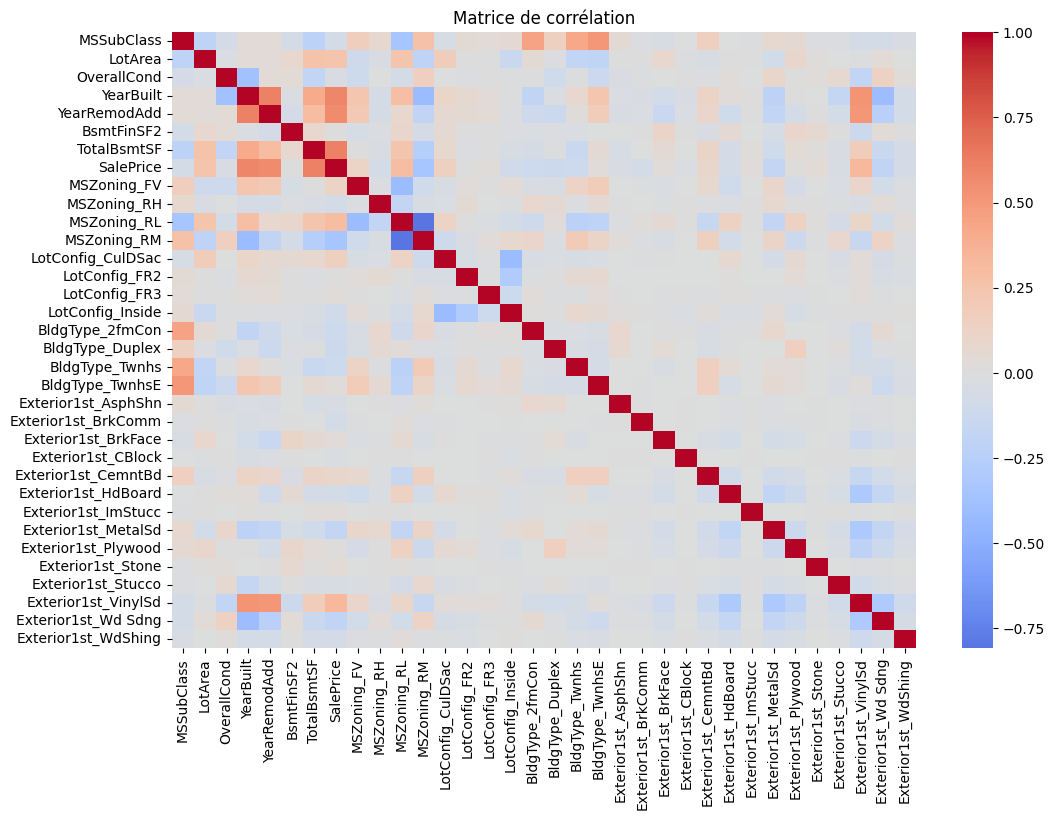

In [44]:
display_corr_matrix(df)

#### 4.1.2 Question 11 (5 points)

On peut alors choisir de supprimer les attributs qui sont fortement corrélées entre eux en définissant un seuil. Fixons ce seuil à 0.7.

**Quels sont les attributs fortement correlés selon le critère ci-dessus ? Supprimez ces attributs et affichez la nouvelle matrice de corrélation.**

Nous avons choisi de programmer de ne conserver que les valeurs absolues. En effet, le signe de la corrélation importe peu dans ce contexte ; c'est surtout l'intensité et la présence d'une corrélation qui nous intéressent ici.

Si on veut afficher le signe des valeurs dans la matrice, on prendra le soin d'enlever la fonction abs() dans cette ligne :

corr_matrix = df.corr(numeric_only=True).abs()

et

sns.heatmap(df_reduced.corr(numeric_only=True).abs(), cmap="coolwarm", center=0)

Attributs fortement corrélés (|corr| > 0.7) : {'MSZoning_RM'}


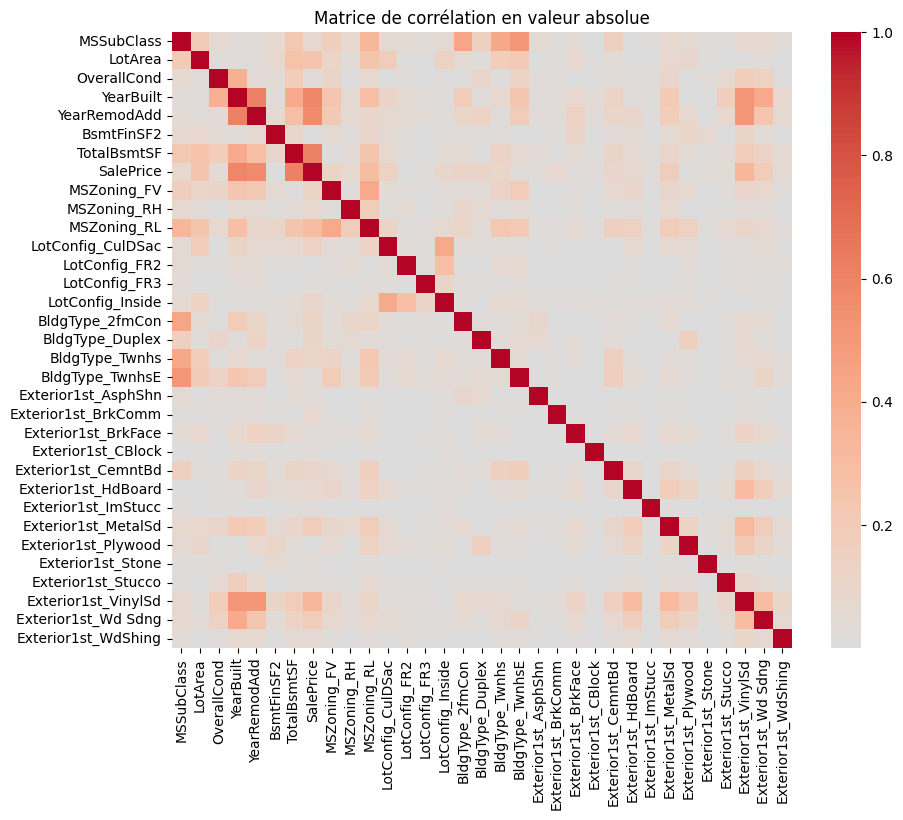

In [45]:
# Matrice de corrélation
corr_matrix = df.corr(numeric_only=True).abs()

# Trouver les paires corrélées au-dessus du seuil
seuil = 0.7
correlated_features = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > seuil:
            colname = corr_matrix.columns[i]
            correlated_features.add(colname)

print("Attributs fortement corrélés (|corr| > 0.7) :", correlated_features)

# Supprimer ces colonnes du DataFrame
df_reduced = df.drop(columns=correlated_features)

# Nouvelle matrice de corrélation
plt.figure(figsize=(10,8))
sns.heatmap(df_reduced.corr(numeric_only=True).abs(), cmap="coolwarm", center=0)
plt.title("Matrice de corrélation en valeur absolue")
plt.show()


## 5. Entrainement d'un modèle de régression linéaire (30 points)

### 5.1 Rappel du concept

La régression linéaire consiste à trouver une fonction affine qui minimise la somme des carrés des erreurs. La fonction affine est définie par la formule suivante :
$$ f(x) = \beta_0 + \beta_1^T x $$
Nous tentons de trouver les paramètres $\beta_0$ et $\beta_1$ qui minimisent $\sum_{i=1}^n (f(x_i) - y_i)^2=||y-X\beta||^2$ où $X$ est la matrice des données fournies au modèle et $y$ le vecteur des `SalePrice`.

On veut trouver le minimum de cette fonction. On va utiliser `RidgeRegression` de `sklearn` pour trouver les paramètres $\beta_0$ et $\beta_1$. Ce module utilise la méthode des moindres carrés (`numpy.linalg.lstsq`) pour trouver les paramètres $\beta_0$ et $\beta_1$.

### 5.2 Application

#### 5.2.1 Question 12 (5 points)

Après avoir effectué le prétraitement, on peut commencer par séparer les données en un ensemble d'entraînement et un ensemble de test. Pour cela, les 1460 premières lignes contiennent les données d'entrainement. On peut ainsi séparer les données en deux ensembles.

**Compléter la structure suivante afin de diviser les données en deux sous-ensembles.**

In [46]:
# Séparation train / test
data_train = {
    "x": df_reduced.iloc[:1460].drop("SalePrice", axis=1),
    "y": df_reduced.iloc[:1460]["SalePrice"],
    "df_train": df_reduced.iloc[:1460]
}

data_pred = {
    "x": df_reduced.iloc[1460:].drop("SalePrice", axis=1),
    "df_test": df_reduced.iloc[1460:]
}

#### 5.2.2 Question 13 (7.5 points)

Une fois cette séparation faite, on peut utiliser `RidgeRegression` pour effectuer la régression linéaire avec pénalisation de la norme L2.

**Compléter la fonction `ridge_regression`. Elle doit implémenter l'ensemble de la régression.**

*Pour cette question, vous devez retourner les coefficients de la regression linéaire. De plus, cette fonction doit modifier le paramètre `data_pred` en y ajoutant les valeurs prédites.*

**Remarques**:
- La fonction doit retourner un dictionnaire dont les clés sont les noms des attributs et les valeurs, les coefficients correspondants.
- Dans `data_pred`, ajoutez deux colonnes : une première contenant les prédictions (sortie du modèle), et une deuxième avec les prédictions remises à l’échelle originale des prix, en inversant la standardisation et la transformation logarithmique.

In [47]:
def ridge_regression(data_train, data_pred):
    model = linear_model.Ridge(alpha=1.0)
    model.fit(data_train["x"], data_train["y"])

    # Prédictions en échelle normalisée/log
    y_pred_scaled = model.predict(data_pred["x"])
    data_pred["y"] = y_pred_scaled

    # Inverser StandardScaler puis log1p
    y_pred_original = np.expm1(y_pred_scaled * sigma_sale_price + mu_sale_price)
    data_pred["y_original"] = y_pred_original

    # Coefficients par variable
    return dict(zip(data_train["x"].columns, model.coef_))

In [48]:
reg = ridge_regression(data_train, data_pred)

data_pred["y"]

array([-0.68368708, -0.13216452,  0.53704343, ...,  0.22378263,
        0.5199317 ,  0.33790179])

#### 5.2.3 Question 14 (5 points)

**À l’aide d’un histogramme, comparez la distribution des prix prédits à celle des données d’entraînement, en vous assurant que les deux sont représentées à l’échelle originale des prix (c’est-à-dire sans transformation logarithmique ni standardisation). Commentez brièvement.**

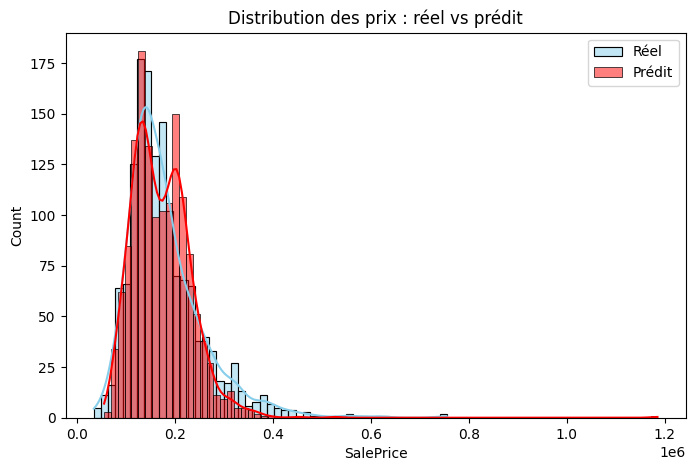

In [49]:
# Créer y_original pour l’ensemble d’entraînement
data_train["y_original"] = np.expm1(data_train["y"] * sigma_sale_price + mu_sale_price)

# Affichage des deux histogramme de comparatif des distributions des prix réels et prédits
plt.figure(figsize=(8,5))
sns.histplot(data_train["y_original"], color="skyblue", label="Réel", kde=True, alpha=0.5)
sns.histplot(data_pred["y_original"], color="red", label="Prédit", kde=True, alpha=0.5)
plt.legend()
plt.title("Distribution des prix : réel vs prédit")
plt.show()

La prédiction est bonne pour la majorité des données, le modèle fonctionne bien globalement, mais il a tendance à lisser les valeurs extrêmes qui sont sous-estimées.

### 5.3. Sélection des attributs importants
#### 5.3.1 Question 15 (5 points)

Une fois la prédiction obtenue, on peut maintenant mesurer l'importance de chaque attribut dans la prédicition en traçant les coefficients de la régression linéaire.

**Quels sont les dix attributs ayant le plus d'impact dans la prédiction ?**


In [51]:
coef_sorted = sorted(reg.items(), key=lambda x: abs(x[1]), reverse=True)[:10]

# Affichage des de l'importance de chaque attribut
for attr, coef in coef_sorted:
    print(f"{attr}: {coef:.4f}")

MSSubClass: 0.4960
TotalBsmtSF: 0.4516
YearBuilt: 0.3499
BldgType_TwnhsE: -0.3457
BldgType_Twnhs: -0.3015
BldgType_2fmCon: -0.2294
YearRemodAdd: 0.1995
BldgType_Duplex: -0.1592
OverallCond: 0.1328
MSZoning_RL: 0.1261


#### 5.3.2 Question 16 (7.5 points)

Cette dernière méthode n'est pas nécessairement une bonne mesure de l'importance d'un attribut. On peut utiliser la méthode SHAP (SHapley Additive exPlanations) pour effectuer la sélection des attributs.

**Les dix attributs ayant le plus d'impact dans la prédiction pour cette mesure sont-ils les mêmes que ceux de la question précédente ? Donnez une interprétation comparative de ces deux résultats**


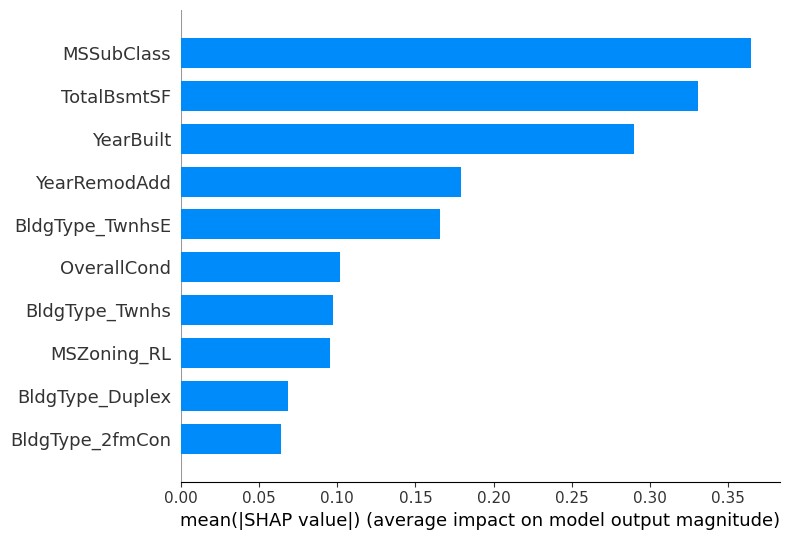

In [52]:
explainer = shap.Explainer(linear_model.Ridge(alpha=1.0).fit(data_train["x"], data_train["y"]), data_train["x"])
shap_values = explainer(data_train["x"])

shap.summary_plot(shap_values, data_train["x"], plot_type="bar", max_display=10)

En comparant les deux méthodes d’évaluation de l’importance des attributs, on observe que le top 10 des variables n’est pas identique. On peut expliquer cela simplement par le fait que les coefficients de la régression linéaire donnent une mesure directe de l’influence de chaque attribut sur la prédiction, en supposant que les autres restent constants. Toutefois, les valeurs SHAP tiennent compte de l’effet marginal de chaque attribut dans le contexte de toutes les interactions possibles avec les autres variables.

## 6. Méthode des écarts interquartiles ou IRQ (10 points)

On peut également détecter les valeurs aberrantes en affichant un boxplot de chaque colonne. On considère les valeurs comme aberrantes si elles sont situées en dehors de l'intervalle [Q1 - α * IQR, Q3 + α * IQR] où
* Q1 et Q3 sont les quantiles 25% et 75%,
* IQR l'intervalle interquartile (Q3 - Q1)
* α le facteur d'ajustement.

Pour cette question, on exclut `SalePrice` car les seules valeurs manquantes de cet attribut sont celles du dataset de test.

**Important :** Pour cette question, utilisez le jeux de données `df_order1` copié vers la fin de la section 2.

### 6.1 Question 17 (5 points)

Testez plusieurs valeurs du facteur d'ajustement α dans l'intervalle [1.5, 5] avec un pas de 0.5.
Pour chaque valeur de α :
- Calculez les bornes de détection des valeurs aberrantes (fences) pour chaque attribut numérique.
- Déterminez le nombre de valeurs aberrantes détectées pour chaque attribut.
- Affichez les résultats dans un `DataFrame`, où les lignes correspondent aux différentes valeurs de α et les colonnes correspondent aux attributs numériques.

**Remarque :** Vous pouvez utiliser la fonction `percentile` de `numpy` pour calculer les quantiles.

In [53]:
num_cols = df_order1.select_dtypes(include=[np.number]).columns.drop("SalePrice")

results = {}
for alpha in np.arange(1.5, 5.5, 0.5):
    outliers_count = {}
    for col in num_cols:
        Q1, Q3 = np.percentile(df_order1[col].dropna(), [25, 75])
        IQR = Q3 - Q1
        lower, upper = Q1 - alpha * IQR, Q3 + alpha * IQR
        outliers = ((df_order1[col] < lower) | (df_order1[col] > upper)).sum()
        outliers_count[col] = outliers
    results[alpha] = outliers_count

df_outliers = pd.DataFrame(results).T

Visualisez les résultats dans une seule figure:
- L’axe X représente les valeurs de α.
- L’axe Y représente le nombre de valeurs aberrantes.
- Chaque courbe correspond à un attribut numérique, illustrant l’évolution du nombre de valeurs aberrantes en fonction de α.

Quelle valeur de α vous semble le mieux adaptée? Justifiez votre réponse.

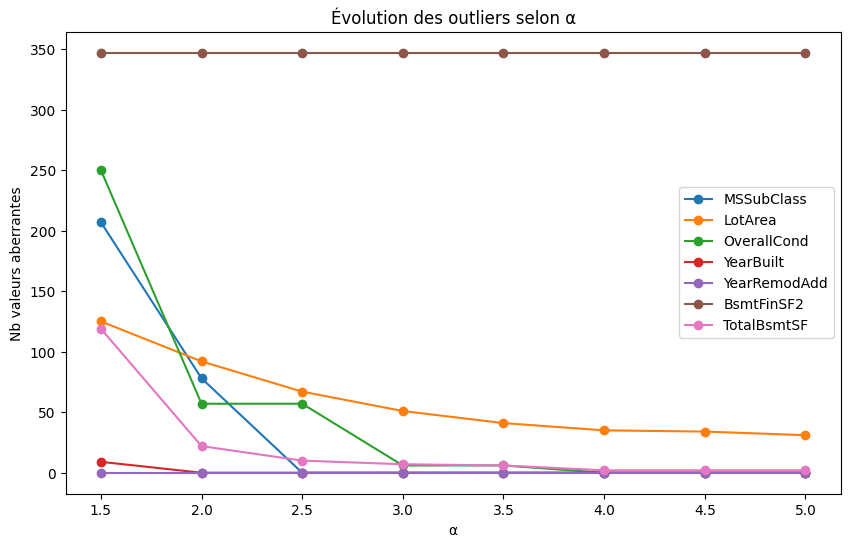

In [54]:
plt.figure(figsize=(10,6))
for col in num_cols:
    plt.plot(df_outliers.index, df_outliers[col], marker='o', label=col)
plt.xlabel("α")
plt.ylabel("Nb valeurs aberrantes")
plt.legend()
plt.title("Évolution des outliers selon α")
plt.show()

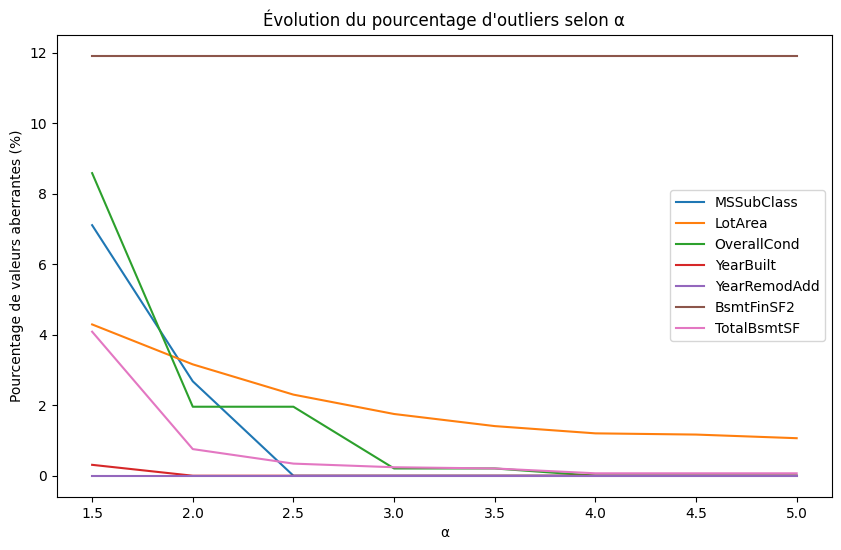

In [55]:
# Calcul du pourcentage d'outliers
df_outliers_pct = df_outliers / len(df_order1) * 100

# Affichage
plt.figure(figsize=(10,6))
for col in num_cols:
    plt.plot(df_outliers_pct.index, df_outliers_pct[col], label=col)
plt.xlabel("α")
plt.ylabel("Pourcentage de valeurs aberrantes (%)")
plt.legend()
plt.title("Évolution du pourcentage d'outliers selon α")
plt.show()

Pour la valeur de alpha, on peut sélectionner la valeur seuil à partir duquel la majorité des colonnes restent sous un pourcentage raisonnable (2% par exemple). Ici, on peut sélectionner alpha = 3 qui remplit ce critère.

### 6.2 Question 18 (5 points)

**On  fixe le facteur d'ajustement α à `3` pour tous les attributs.**

Pour chaque attribut numérique, tracez un boxplot. Ajoutez également deux lignes horizontales représentant les bornes inférieure et supérieure de l’intervalle [Q1 - α * IQR, Q3 + α * IQR].

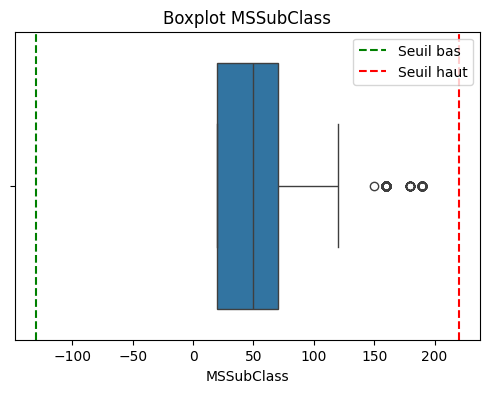

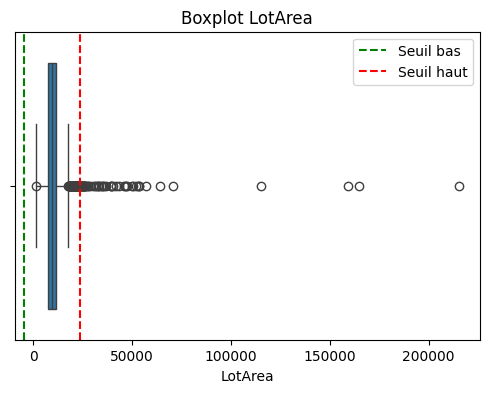

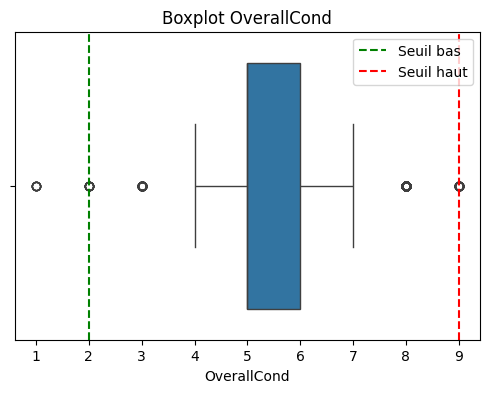

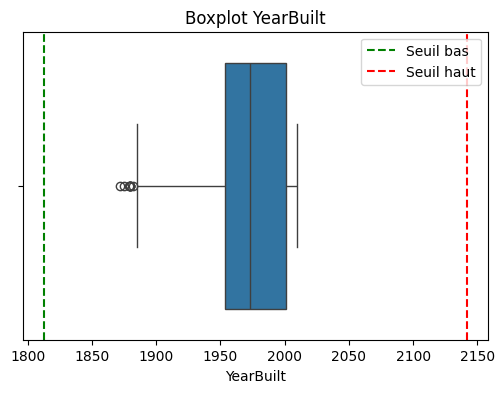

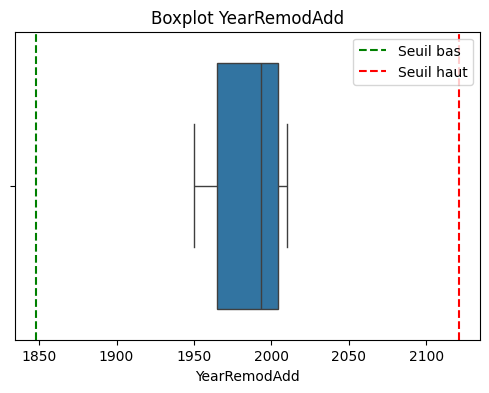

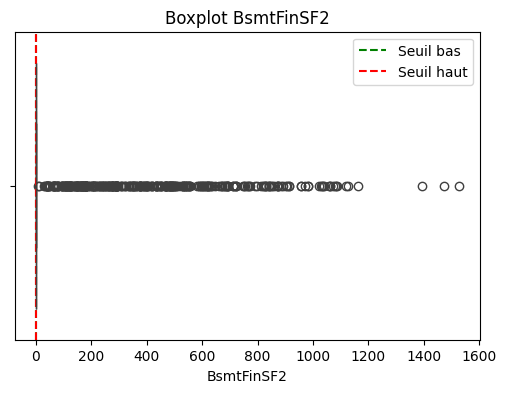

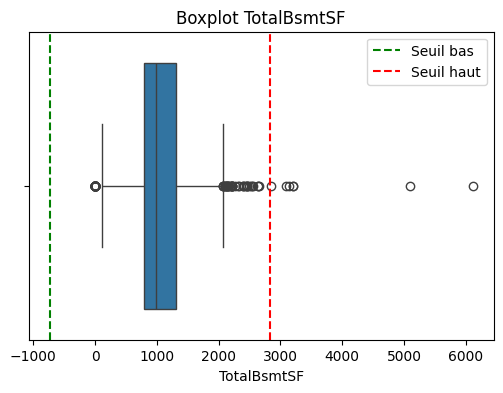

In [63]:
alpha = 3
df_cleaned = df_order1.copy()

for col in num_cols:
    Q1, Q3 = np.percentile(df_order1[col].dropna(), [25, 75])
    IQR = Q3 - Q1
    lower, upper = Q1 - alpha * IQR, Q3 + alpha * IQR

    # affichage des box plot
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_order1[col])
    plt.axvline(lower, color="green", linestyle="--", label="Seuil bas")
    plt.axvline(upper, color="red", linestyle="--", label="Seuil haut")
    plt.title(f"Boxplot {col}")
    plt.legend()
    plt.show()

Pour chaque attribut numérique (à l'exception de `BsmtFinSF2`), remplacez les valeurs aberrantes détectées avec α=3 par la `valeur médiane` de la colonne. Pourquoi ce remplacement n’est pas approprié pour l’attribut `BsmtFinSF2` ?

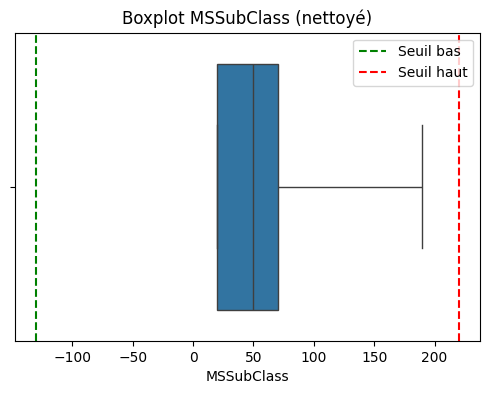

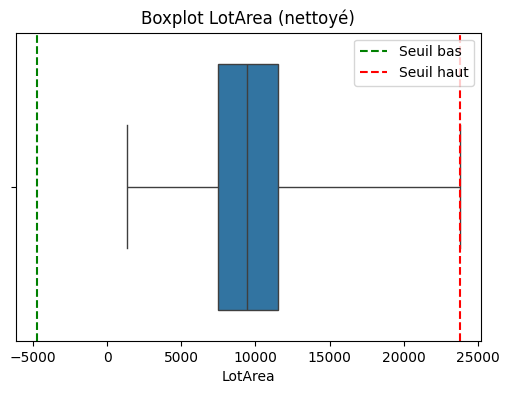

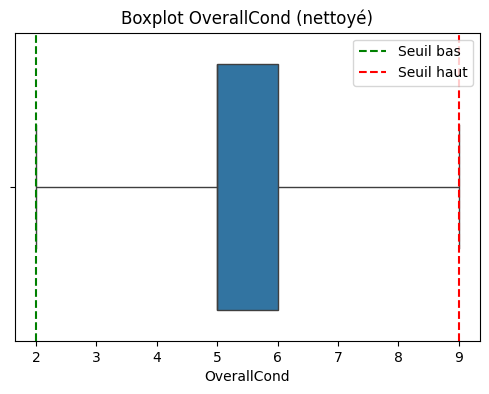

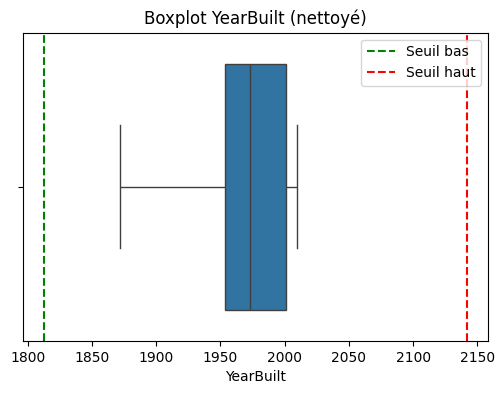

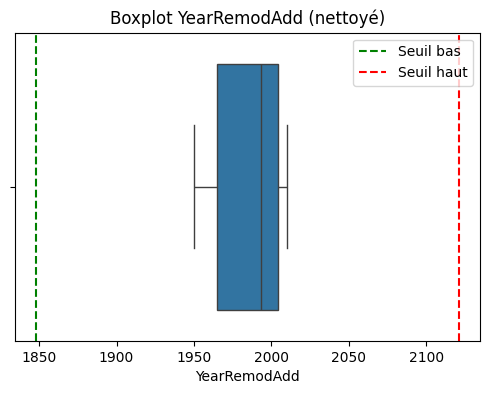

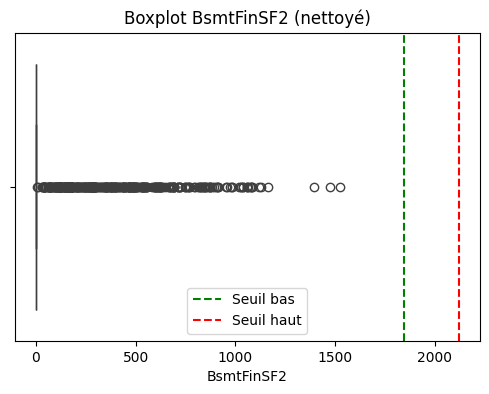

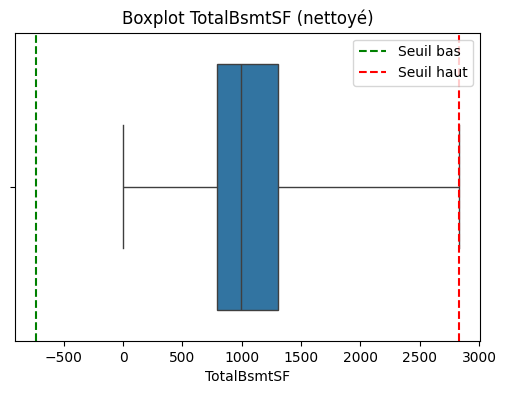

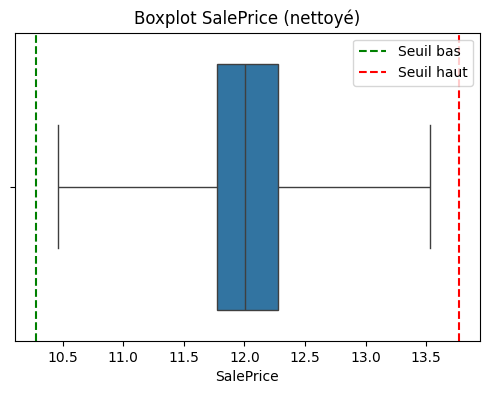

In [77]:
alpha = 3 # Seuil de détection
df_cleaned = df_order1.copy()

for col in df_cleaned.select_dtypes(include=[np.number]).columns:
    if col != "BsmtFinSF2":  # exception
        Q1 = df_cleaned[col].quantile(0.25)
        Q3 = df_cleaned[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - alpha * IQR, Q3 + alpha * IQR

        # On force les valeurs à être dans les bornes du box plot
        df_cleaned[col] = df_cleaned[col].clip(lower, upper)

    # Affichage du boxplot
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df_cleaned[col], whis=alpha)
    plt.axvline(lower, color="green", linestyle="--", label="Seuil bas")
    plt.axvline(upper, color="red", linestyle="--", label="Seuil haut")
    plt.title(f"Boxplot {col} (nettoyé)")
    plt.legend()
    plt.show()


Pour BsmtFinSF2, ce n’est pas approprié car la majorité des valeurs sont nulles (maison sans sous-sol fini → médiane = 0). Remplacer un vrai outlier par 0 pourrait supprimer une information utile.